# Mini caso 2 — Clustering temático y topic modeling

Este notebook desarrolla un análisis no supervisado del corpus documental del 23-F.

El objetivo es comprobar si los documentos pueden agruparse automáticamente en familias temáticas o documentales a partir de su contenido textual. A diferencia de la clasificación institucional, aquí no se utiliza ninguna etiqueta como variable objetivo.

La primera aproximación se realizará mediante TF-IDF y K-Means. La interpretación de los clusters se apoyará en:

- los términos más representativos de cada grupo;
- el número de documentos asignados a cada cluster;
- ejemplos de títulos dentro de cada grupo;
- una visualización bidimensional de los documentos.

El objetivo no es sustituir la lectura documental, sino facilitar una primera navegación del corpus y detectar posibles bloques temáticos recurrentes.

In [1]:
from pathlib import Path

import pandas as pd

# Localización robusta de la raíz del repositorio.
# Así el notebook funciona tanto si se ejecuta desde la raíz como desde /notebooks.
current_path = Path.cwd().resolve()

if (current_path / "data").exists() and (current_path / "notebooks").exists():
    ROOT = current_path
elif (current_path.parent / "data").exists() and (current_path.parent / "notebooks").exists():
    ROOT = current_path.parent
else:
    raise FileNotFoundError("No se ha podido localizar la raíz del repositorio.")

DATA_PROCESSED = ROOT / "data" / "processed"

input_path = DATA_PROCESSED / "rtve_corpus_clean_base.csv"

df = pd.read_csv(input_path)

print(f"Archivo cargado: {input_path}")
print(f"Dimensiones: {df.shape}")

display(df.head())

Archivo cargado: /Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/data/processed/rtve_corpus_clean_base.csv
Dimensiones: (167, 25)


,doc_id,source_document_id,title,pages,detail_url,pdf_url,summary,keywords,text_full,text_clean_base,...,moncloa_section,moncloa_subsection,final_match_status,coverage_moncloa,alpha_ratio,digit_ratio,uppercase_ratio,weird_char_ratio,n_title_years,title_main_year
0,rtve_1860,1860,Vista oral 2/81 del Consejo Supremo de Justici...,3,https://23fbuscador.rtve.es/document/ocr/1860?...,https://www.rtve.es/contenidos/documentos/23f-...,El juicio oral 2/81 celebrado en febrero de 19...,C/SG/2820/20-02-82 DTOR. Vista oral 2/81,C/SG/2820/20-02-82\nDTOR.\n\nNOTA INFORMATIVA\...,C/SG/2820/20-02-82\nDTOR.\n\nNOTA INFORMATIVA\...,...,defensa,cni,high_confidence_match,True,0.777834,0.013726,0.147386,0.000000,1,1982.0
1,rtve_1859,1859,Vista oral 2/81 del Consejo Supremo de Justici...,4,https://23fbuscador.rtve.es/document/ocr/1859?...,https://www.rtve.es/contenidos/documentos/23f-...,Resumen global del documento:\n\nEl documento ...,C/SG/2896/22-02-82 Vista oral 2/81 Consejo Sup...,C/SG/2896/22-02-82\n\n# NOTA INFORMATIVA\n\nAS...,C/SG/2896/22-02-82\n\n# NOTA INFORMATIVA\n\nAS...,...,defensa,cni,high_confidence_match,True,0.781985,0.009506,0.195895,0.000156,1,1982.0
2,rtve_1858,1858,Vista oral 2/81 del Consejo Supremo de Justici...,5,https://23fbuscador.rtve.es/document/ocr/1858?...,https://www.rtve.es/contenidos/documentos/23f-...,Resumen global del documento:\n\nEl documento ...,C/SG/2992/24-02-82 Vista Oral 2/81 Consejo Sup...,C/SG/2992/24-02-82\n\n# NOTA INFORMATIVA\n\nAS...,C/SG/2992/24-02-82\n\n# NOTA INFORMATIVA\n\nAS...,...,defensa,cni,high_confidence_match,True,0.784920,0.011487,0.124085,0.000611,1,1982.0
3,rtve_1857,1857,Vista oral 2/81 del Consejo Supremo de Justici...,6,https://23fbuscador.rtve.es/document/ocr/1857?...,https://www.rtve.es/contenidos/documentos/23f-...,El documento recoge el desarrollo de la sesión...,C/SG/3.081/25-02-82 Vista Oral 2/81 Consejo Su...,C/SG/3.081/25-02-82\n\n# NOTA INFORMATIVA\n\nA...,C/SG/3.081/25-02-82\n\n# NOTA INFORMATIVA\n\nA...,...,defensa,cni,high_confidence_match,True,0.789257,0.008250,0.128167,0.000538,1,1982.0
4,rtve_1856,1856,Vista oral 2/81 del Consejo Supremo de Justici...,6,https://23fbuscador.rtve.es/document/ocr/1856?...,https://www.rtve.es/contenidos/documentos/23f-...,Resumen global del documento sobre la sesión d...,C/SG/3.249/26-02-82 SG Consejo Supremo de Just...,C/SG/3.249/26-02-82\nSG\n\n# NOTA INFORMATIVA\...,C/SG/3.249/26-02-82\nSG\n\n# NOTA INFORMATIVA\...,...,defensa,cni,high_confidence_match,True,0.786053,0.008593,0.066097,0.000691,1,1982.0


## 1. Selección de datos

En este mini caso se trabaja con los 167 documentos del corpus limpio. Se utiliza `text_clean_base` como texto principal y se conserva `doc_id` para mantener la trazabilidad de cada documento.

El análisis es no supervisado: no se utiliza ninguna etiqueta como variable objetivo. La columna `moncloa_section` se mantiene únicamente como metadato auxiliar para interpretar los resultados al final, pero no se usará para construir los clusters.

También se conserva `title`, ya que permite revisar manualmente ejemplos de documentos dentro de cada grupo.

In [2]:
df_text = df[
    [
        "doc_id",
        "title",
        "text_clean_base",
        "text_clean_length_words",
        "moncloa_section",
    ]
].copy()

df_text = df_text[
    df_text["text_clean_base"].notna()
    & (df_text["text_clean_length_words"] >= 50)
].copy()

print("Documentos seleccionados para clustering:")
print(df_text.shape)

print("\nResumen de longitud de los textos seleccionados:")
display(df_text["text_clean_length_words"].describe().to_frame().T)

display(
    df_text[
        ["doc_id", "title", "text_clean_length_words", "moncloa_section"]
    ].head()
)

Documentos seleccionados para clustering:
(167, 5)

Resumen de longitud de los textos seleccionados:


,count,mean,std,min,25%,50%,75%,max
text_clean_length_words,167.0,2075.443114,7731.242472,72.0,238.5,579.0,1771.5,95293.0


,doc_id,title,text_clean_length_words,moncloa_section
0,rtve_1860,Vista oral 2/81 del Consejo Supremo de Justici...,640,defensa
1,rtve_1859,Vista oral 2/81 del Consejo Supremo de Justici...,1018,defensa
2,rtve_1858,Vista oral 2/81 del Consejo Supremo de Justici...,1347,defensa
3,rtve_1857,Vista oral 2/81 del Consejo Supremo de Justici...,1826,defensa
4,rtve_1856,Vista oral 2/81 del Consejo Supremo de Justici...,1740,defensa


## 2. Preprocesamiento textual

Antes de vectorizar los documentos se aplica una limpieza textual sencilla orientada al clustering.

El objetivo no es modificar el significado del documento, sino reducir ruido básico que puede dominar el cálculo de similitud: mayúsculas, signos sueltos, números aislados, palabras vacías y términos demasiado cortos.

En esta primera versión no se aplica lematización, porque añadiría dependencia de modelos lingüísticos externos y complicaría el notebook. Si más adelante fuera necesario, podría incorporarse como mejora.

In [3]:
import re

stopwords_es = {
    "a", "al", "algo", "ante", "antes", "como", "con", "contra", "cual",
    "cuando", "de", "del", "desde", "donde", "durante", "e", "el", "ella",
    "ellas", "ellos", "en", "entre", "era", "eran", "es", "esa", "esas",
    "ese", "eso", "esos", "esta", "estaba", "estado", "estan", "estar",
    "este", "esto", "estos", "fue", "fueron", "ha", "habia", "han", "hasta",
    "hay", "la", "las", "le", "les", "lo", "los", "mas", "más", "me", "mi", "muy",
    "no", "nos", "o", "para", "pero", "por", "porque", "que", "se", "sin",
    "sobre", "son", "su", "sus", "tambien", "te", "tiene", "un", "una",
    "unas", "uno", "unos", "y", "ya"
}

stopwords_en = {
    "the", "and", "of", "to", "in", "that", "is", "was", "for", "on",
    "with", "as", "by", "at", "from", "it", "this", "be", "or", "an",
    "you", "your", "have", "has", "had", "are", "were", "they", "their",
    "we", "he", "his", "she", "her", "them"
}

stopwords_custom = {
    # términos genéricos del corpus o del formato documental
    "documento", "documentos", "pagina", "paginas", "pdf", "rtve",
    
    # restos de OCR, imágenes o referencias internas
    "img", "jpeg", "dtor",
    
    # fórmulas administrativas demasiado frecuentes
    "excmo", "núm", "num", "ref", "señor",
    "dios", "guarde", "muchos", "años",
    
    # términos demasiado genéricos para separar temas
    "todos", "parte"
}

stopwords = stopwords_es | stopwords_en | stopwords_custom


def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"[^a-záéíóúüñ\s]", " ", text)
    tokens = text.split()

    tokens_clean = [
        token
        for token in tokens
        if len(token) >= 3 and token not in stopwords
    ]

    return " ".join(tokens_clean)


df_text["text_processed"] = df_text["text_clean_base"].apply(preprocess_text)

print("Preprocesamiento aplicado.")
print("Ejemplo antes:")
print(df_text["text_clean_base"].iloc[0][:500])

print("\nEjemplo después:")
print(df_text["text_processed"].iloc[0][:500])

Preprocesamiento aplicado.
Ejemplo antes:
C/SG/2820/20-02-82
DTOR.

NOTA INFORMATIVA

ASUNTO: Vista oral 2/81

1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82

- Solo ha tenido lugar la sesión de la mañana. Empezó a las 10,06 horas.

- Durante la sesión han tenido lugar, a petición del Sr. Fiscal las declaraciones siguientes:

. Parcial de Teniente Coronel D. Luis Arana Lorite (Ayte. Gral. Lluch).

. Parcial de Teniente Coronel D. Manuel Miler Hidalgo (Ayte. Gral. Esquivias).

. 1a, 2a, 3a y 4a del Teniente Coronel TEJERO.

. Ca

Ejemplo después:
nota informativa asunto vista oral desarrollo sesión correspondiente solo tenido lugar sesión mañana empezó horas sesión tenido lugar petición fiscal declaraciones siguientes parcial teniente coronel luis arana lorite ayte gral lluch parcial teniente coronel manuel miler hidalgo ayte gral esquivias teniente coronel tejero careo teniente coronel tejero carres descanso horas horas careo teniente coronel tejero capitán gomez iglesias cert

### Lectura del bloque

El preprocesamiento aplicado es deliberadamente sencillo. Se parte de `text_clean_base` y se genera una nueva columna, `text_processed`, pensada específicamente para la vectorización textual del clustering.

La limpieza convierte el texto a minúsculas, elimina URLs, signos no alfabéticos, números aislados, palabras vacías frecuentes y términos demasiado cortos. Con ello se evita que palabras funcionales como `de`, `el`, `que`, `la`, `the` o `and` dominen la representación TF-IDF.

No se aplica lematización en esta primera versión. La decisión se toma para mantener el notebook simple, reproducible y fácil de defender. Si los resultados posteriores muestran clusters poco interpretables, la lematización podría incorporarse como mejora futura.

## 3. Vectorización TF-IDF

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=3000,
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2)
)

X_tfidf = vectorizer.fit_transform(df_text["text_processed"])

print("Matriz TF-IDF creada:")
print(X_tfidf.shape)

print("\nNúmero de términos en el vocabulario:")
print(len(vectorizer.get_feature_names_out()))

print("\nPrimeros términos del vocabulario:")
print(vectorizer.get_feature_names_out()[:30])

Matriz TF-IDF creada:
(167, 3000)

Número de términos en el vocabulario:
3000

Primeros términos del vocabulario:
['abad' 'abajo' 'abandonado' 'abandonar' 'abierto' 'abogado'
 'abogado defensor' 'abogados' 'abogados defensores' 'abrazo' 'abril'
 'absolución' 'absoluta' 'absoluta normalidad' 'absolutamente' 'absoluto'
 'acaba' 'acaban' 'acabar' 'academia' 'academia tráfico' 'acaecidos'
 'acaso' 'acceso' 'accion' 'acciones' 'acción' 'acepta' 'aceptación'
 'aceptado']


### Lectura del bloque

La vectorización TF-IDF transforma cada documento en una representación numérica basada en la importancia relativa de sus términos dentro del corpus.

En esta versión se limita el vocabulario a un máximo de 3000 términos, se eliminan términos que aparecen en un solo documento y también aquellos demasiado frecuentes en el conjunto del corpus. Además, se incluyen unigramas y bigramas para conservar expresiones relevantes como `guardia civil`, `teniente coronel` o `abogado defensor`.

Esta representación será la entrada del algoritmo de clustering. No se utiliza ninguna etiqueta institucional para crear la matriz, por lo que el análisis sigue siendo no supervisado.

## 4. Selección del número de clusters

Antes de entrenar un modelo final de K-Means, se prueban varios valores de `k`.

Como no existe una etiqueta real contra la que comparar, la evaluación se basa en métricas internas y en la interpretabilidad posterior de los grupos. El objetivo no es encontrar un valor “perfecto”, sino seleccionar un número de clusters razonable para explorar el corpus.

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results = []

for k in range(2, 9):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = model.fit_predict(X_tfidf)
    
    silhouette = silhouette_score(
        X_tfidf,
        labels,
        metric="cosine"
    )
    
    cluster_sizes = pd.Series(labels).value_counts().sort_index().tolist()
    
    results.append({
        "k": k,
        "silhouette_cosine": silhouette,
        "inertia": model.inertia_,
        "cluster_sizes": cluster_sizes
    })

df_k_results = pd.DataFrame(results)

display(df_k_results)

,k,silhouette_cosine,inertia,cluster_sizes
0,2,0.059532,143.771684,"[56, 111]"
1,3,0.080795,139.047639,"[77, 29, 61]"
2,4,0.084929,134.979093,"[67, 27, 30, 43]"
3,5,0.098690,132.808930,"[38, 52, 46, 9, 22]"
4,6,0.080090,130.051648,"[33, 27, 45, 18, 35, 9]"
5,7,0.078209,127.310086,"[9, 43, 44, 18, 24, 26, 3]"
6,8,0.085010,125.596883,"[16, 11, 40, 9, 60, 9, 9, 13]"


### Lectura del bloque

Se han probado distintos valores de `k` entre 2 y 8 para evitar fijar manualmente el número de clusters sin justificación.

El mejor valor de Silhouette con distancia coseno se obtiene con `k = 5`. Aunque el valor absoluto de la métrica no es alto, resulta razonable en un corpus documental histórico, heterogéneo y con textos de longitudes muy distintas.

La solución con cinco clusters también mantiene tamaños de grupo interpretables: no divide el corpus en demasiados grupos pequeños y permite revisar posteriormente términos y ejemplos de documentos por cluster.

Por tanto, se selecciona `k = 5` como primera solución de trabajo. Esta elección no debe interpretarse como una clasificación definitiva del corpus, sino como una segmentación exploratoria que necesita revisión cualitativa.

## 5. Entrenamiento final del modelo de clustering

In [6]:
# Entrenamiento final con el número de clusters seleccionado
k_final = 5

kmeans_final = KMeans(
    n_clusters=k_final,
    random_state=42,
    n_init=10
)

df_text["cluster"] = kmeans_final.fit_predict(X_tfidf)

cluster_summary = (
    df_text["cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="n_documentos")
)

cluster_summary["porcentaje"] = (
    cluster_summary["n_documentos"] / len(df_text) * 100
).round(2)

display(cluster_summary)

,cluster,n_documentos,porcentaje
0,0,38,22.75
1,1,52,31.14
2,2,46,27.54
3,3,9,5.39
4,4,22,13.17


### Lectura del bloque

Con `k = 5`, el corpus queda repartido en cinco grupos de tamaño desigual. Esta distribución es razonable para un corpus documental heterogéneo: algunos clusters agrupan bloques amplios de documentos similares, mientras que otros recogen subconjuntos más específicos.

El cluster 1 es el más grande, con 52 documentos, seguido del cluster 2 con 46 documentos y del cluster 0 con 38 documentos. Los clusters 3 y 4 son más pequeños, por lo que deberán revisarse con especial atención para comprobar si representan subconjuntos temáticos concretos o documentos con características particulares.

A partir de este punto, la calidad del clustering no debe evaluarse solo mediante una métrica interna. Al tratarse de un problema no supervisado, la interpretación de los términos principales y de ejemplos de documentos por cluster será necesaria para valorar si los grupos tienen sentido documental.

## 6. Interpretación de clusters

In [7]:
terms = vectorizer.get_feature_names_out()

cluster_terms = []

for cluster_id in range(k_final):
    center = kmeans_final.cluster_centers_[cluster_id]
    top_indices = center.argsort()[-15:][::-1]
    top_terms = [terms[i] for i in top_indices]
    
    cluster_terms.append({
        "cluster": cluster_id,
        "n_documentos": int(cluster_summary.loc[
            cluster_summary["cluster"] == cluster_id,
            "n_documentos"
        ].iloc[0]),
        "terminos_representativos": ", ".join(top_terms)
    })

df_cluster_terms = pd.DataFrame(cluster_terms)

display(df_cluster_terms)

,cluster,n_documentos,terminos_representativos
0,0,38,"fas, militar, gobierno, golpe, militares, pued..."
1,1,52,"general, armada, coronel, teniente, capitán, t..."
2,2,46,"general, justicia, consejo, militar, don, madr..."
3,3,9,"spain, spanish, democracy, democratic, haig, p..."
4,4,22,"exteriores, asuntos exteriores, asuntos, españ..."


In [8]:
pd.set_option("display.max_colwidth", 300)

df_cluster_terms

,cluster,n_documentos,terminos_representativos
0,0,38,"fas, militar, gobierno, golpe, militares, puede, general, está, partido, proceso, ser, todo, procesados, sentencia, otra"
1,1,52,"general, armada, coronel, teniente, capitán, tejero, tcol, gral, fiscal, general armada, congreso, defensor, civil, guardia, guardia civil"
2,2,46,"general, justicia, consejo, militar, don, madrid, jefe, ministro defensa, justicia militar, defensa, consejo supremo, ministro, supremo, togado, fecha"
3,3,9,"spain, spanish, democracy, democratic, haig, people, king, united, united states, states, institutions, america, reagan, washington, spanish democracy"
4,4,22,"exteriores, asuntos exteriores, asuntos, españa, embajador, espanha, marzo, presidente, agradezco, español, europa, democráticas, ministro asuntos, majestad, die"


In [9]:
for cluster_id in range(k_final):
    print("\n" + "="*80)
    print(f"CLUSTER {cluster_id}")
    print("="*80)
    
    ejemplos = (
        df_text[df_text["cluster"] == cluster_id]
        [["doc_id", "title", "text_clean_length_words", "moncloa_section"]]
        .sort_values("text_clean_length_words", ascending=False)
        .head(5)
    )
    
    display(ejemplos)


CLUSTER 0


,doc_id,title,text_clean_length_words,moncloa_section
161,rtve_1699,Transcripción de cintas grabadas con conversaciones telefónicas con varias personas intervenidas a la esposa de Tejero.,95293,interior
76,rtve_1784,Policía Nacional. Informe de situación. Marca: reservado-confidencial (12 de noviembre de 1981).,13639,interior
74,rtve_1786,"""Juicio del 23-F: acotaciones al desarrollo del juicio",11080,interior
157,rtve_1703,Semestral de la amenaza interior (10 de febrero de 1981; 9 de marzo de 1981).,8714,defensa
93,rtve_1767,"""Informe de las distintas Jefaturas Superiores: Comisaría General de Información. """"Situación actual en las distintas regiones policiales y acciones de protesta previstas en relación a la ocupación del Palacio del Congreso de los Diputados"""" (26 de febrero de 1981).""",7189,interior



CLUSTER 1


,doc_id,title,text_clean_length_words,moncloa_section
126,rtve_1734,"""Nota Informativa sobre la repercusión en prensa del arresto de Tejero en 1978 cuando era Jefe de la Comandancia de Málaga",10253,interior
50,rtve_1810,Relato de los sucesos de los días 23 y 24 de febrero.,8965,defensa
49,rtve_1811,Vista oral 2/81 del Consejo Supremo de Justicia Militar (24 de mayo de 1982).,4184,defensa
73,rtve_1787,"""Nota """"Campaña contra S.M."""" (sin firma).""",4105,interior
22,rtve_1838,Vista oral 2/81 del Consejo Supremo de Justicia Militar (30 de marzo de 1982).,3827,defensa



CLUSTER 2


,doc_id,title,text_clean_length_words,moncloa_section
159,rtve_1701,Télex interiores y de agencias recibidos en 2ª sección EM el día 23-F informando del estado de situación (23 de febrero de 1981).,19857,interior
63,rtve_1797,Investigación y declaraciones personal AOME por JDDI (9 de abril de 1981).,14485,defensa
65,rtve_1795,Actitud del CESID ante la situación provocada por los incidentes en el Congreso.,2648,defensa
64,rtve_1796,Informe sobre la participación de miembros de la AOME (CESID) en los hechos del 23 de febrero de 1981.,1753,defensa
119,rtve_1741,SECRETO: información sobre circunstancias de la detención de Milans del Bosch.,1218,defensa



CLUSTER 3


,doc_id,title,text_clean_length_words,moncloa_section
84,rtve_1776,D.31._AGA-83-09301_exp._5,1926,exteriores
109,rtve_1751,D.8._AGMAE_R39017_Exp._4,651,exteriores
102,rtve_1758,D.14._AGMAE_R39017_Exp._4,650,exteriores
116,rtve_1744,D.2._AGMAE_R39017_Exp._4,354,NaN
114,rtve_1746,D.3._AGMAE_R39017_Exp._4,269,exteriores



CLUSTER 4


,doc_id,title,text_clean_length_words,moncloa_section
97,rtve_1763,D.19._AGA-83-07633_exp._4,579,exteriores
98,rtve_1762,D.18._AGA-83-07633_exp._4,521,exteriores
90,rtve_1770,D.25._AGA-83-08764_exp._5,445,exteriores
95,rtve_1765,D.21._AGA-83-07633_exp._4,423,exteriores
94,rtve_1766,D.22._AGA-83-07633_exp._4,417,exteriores


### Lectura del bloque

La revisión de ejemplos permite comprobar que los clusters no se explican únicamente por términos aislados, sino que agrupan documentos con cierta coherencia documental.

El cluster 0 reúne documentos extensos relacionados con informes de situación, transcripciones, amenaza interior y documentación policial o de seguimiento. El cluster 1 agrupa documentos vinculados a la vista oral, el Consejo Supremo de Justicia Militar, el relato de los sucesos y documentación centrada en Tejero o el desarrollo judicial posterior. El cluster 2 concentra documentos de carácter militar-operativo, con presencia de télex, CESID, AOME, Milans del Bosch e informes de defensa. El cluster 3 recoge documentos de Exteriores con una dimensión internacional más marcada, incluyendo vocabulario en inglés y referencias a España, democracia, Estados Unidos o actores internacionales. El cluster 4 también está asociado a Exteriores, pero parece recoger documentos más breves y administrativos, especialmente expedientes AGA.

Esta revisión confirma que la agrupación obtenida es interpretable y aporta una primera segmentación temática del corpus. Aun así, los clusters no deben entenderse como categorías cerradas: al tratarse de un método no supervisado, la interpretación depende de la combinación entre métricas internas, términos representativos y revisión cualitativa de documentos.

In [10]:
cluster_labels = {
    0: "Informes extensos, seguimiento policial y amenaza interior",
    1: "Vista oral, relato de sucesos y documentación judicial amplia",
    2: "Defensa, justicia militar y documentación operativa",
    3: "Exteriores con dimensión internacional",
    4: "Exteriores administrativo y expedientes breves"
}

df_cluster_summary = cluster_summary.copy()
df_cluster_summary["interpretacion"] = df_cluster_summary["cluster"].map(cluster_labels)

df_cluster_summary = df_cluster_summary[
    ["cluster", "interpretacion", "n_documentos", "porcentaje"]
]

display(df_cluster_summary)

,cluster,interpretacion,n_documentos,porcentaje
0,0,"Informes extensos, seguimiento policial y amenaza interior",38,22.75
1,1,"Vista oral, relato de sucesos y documentación judicial amplia",52,31.14
2,2,"Defensa, justicia militar y documentación operativa",46,27.54
3,3,Exteriores con dimensión internacional,9,5.39
4,4,Exteriores administrativo y expedientes breves,22,13.17


### Lectura del bloque

La tabla resume la interpretación manual de los cinco clusters obtenidos. Esta interpretación se basa en la combinación de tres elementos: los términos representativos de cada grupo, los ejemplos de documentos revisados y el tamaño relativo de cada cluster.

Los clusters 0, 1 y 2 concentran la mayor parte del corpus y representan tres bloques documentales amplios: informes extensos de seguimiento o amenaza interior, documentación judicial vinculada al relato de los sucesos y un bloque militar-operativo con comunicaciones internas e informes de defensa.

Los clusters 3 y 4 son más pequeños y están vinculados a documentación de Exteriores. Sin embargo, no representan exactamente lo mismo: el cluster 3 recoge documentos con mayor dimensión internacional, mientras que el cluster 4 agrupa expedientes más breves y administrativos.

Esta tabla no debe entenderse como una clasificación definitiva, sino como una síntesis interpretativa del resultado no supervisado. Su utilidad principal es facilitar la navegación inicial del corpus y detectar familias documentales que podrían analizarse con más detalle en fases posteriores.

## 7. Visualización bidimensional de los clusters

Para facilitar la interpretación visual de los grupos, se reduce la matriz TF-IDF a dos dimensiones mediante `TruncatedSVD`.

Esta visualización no se utiliza para entrenar el modelo, sino únicamente para representar de forma aproximada la distribución de documentos y clusters en un plano bidimensional.

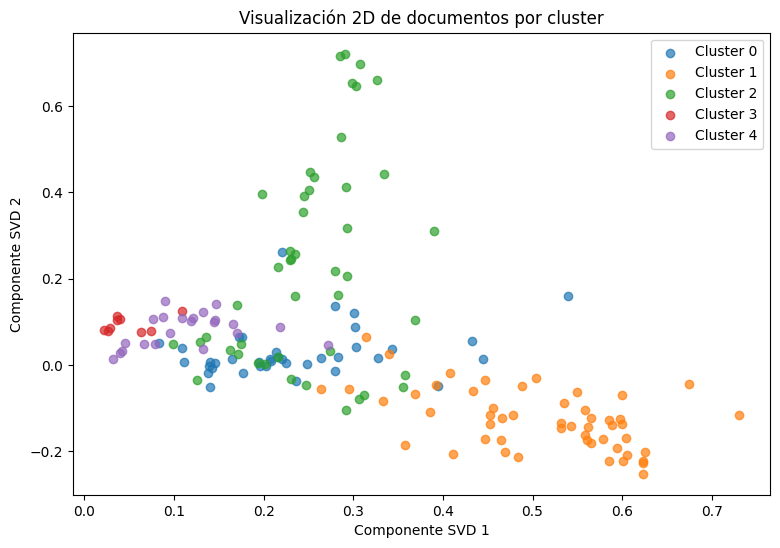

Varianza explicada aproximada por las dos componentes:
0.0751


In [11]:
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

svd = TruncatedSVD(n_components=2, random_state=42)
coords_2d = svd.fit_transform(X_tfidf)

df_text["svd_1"] = coords_2d[:, 0]
df_text["svd_2"] = coords_2d[:, 1]

plt.figure(figsize=(9, 6))

for cluster_id in range(k_final):
    cluster_data = df_text[df_text["cluster"] == cluster_id]
    plt.scatter(
        cluster_data["svd_1"],
        cluster_data["svd_2"],
        label=f"Cluster {cluster_id}",
        alpha=0.7
    )

plt.title("Visualización 2D de documentos por cluster")
plt.xlabel("Componente SVD 1")
plt.ylabel("Componente SVD 2")
plt.legend()
plt.show()

print("Varianza explicada aproximada por las dos componentes:")
print(round(svd.explained_variance_ratio_.sum(), 4))

### Lectura del bloque

La visualización bidimensional permite observar de forma aproximada cómo se distribuyen los documentos según la representación TF-IDF y los clusters obtenidos.

El gráfico muestra cierta separación entre algunos grupos, especialmente en el caso de documentos con perfiles más diferenciados. Sin embargo, también se observa solapamiento entre clusters, algo esperable en un corpus histórico donde muchos documentos comparten vocabulario militar, judicial, político e institucional.

La varianza explicada por las dos componentes SVD es reducida, por lo que esta figura debe interpretarse únicamente como una ayuda visual. La interpretación principal del clustering se basa en la combinación de métricas internas, términos representativos y revisión de ejemplos documentales.

## 8. Conclusiones y limitaciones

El mini caso ha permitido construir una primera agrupación temática no supervisada del corpus documental del 23-F. A partir de `text_clean_base`, se ha aplicado un preprocesamiento textual específico, una vectorización TF-IDF y un modelo K-Means con cinco clusters.

Los resultados muestran una segmentación interpretable del corpus. Se identifican grupos asociados a informes extensos y seguimiento policial, documentación judicial y vista oral, comunicaciones militares internas, documentos internacionales y expedientes administrativos de Exteriores.

La interpretación de los clusters se ha realizado combinando métricas internas, términos representativos, ejemplos de documentos y visualización bidimensional. Esta combinación es necesaria porque, al tratarse de aprendizaje no supervisado, no existe una etiqueta real contra la que validar directamente los grupos.

La visualización mediante SVD debe interpretarse con cautela, ya que solo representa una parte reducida de la información contenida en la matriz TF-IDF. Por tanto, el gráfico sirve como apoyo visual, pero no como prueba definitiva de separación entre clusters.

Como limitación principal, el modelo K-Means obliga a asignar cada documento a un único cluster, aunque algunos documentos pueden mezclar contenido militar, judicial, policial, político e internacional. Además, el resultado depende del preprocesamiento textual y de los parámetros escogidos en la vectorización.

Como ampliación futura, podrían evaluarse otros enfoques de topic modeling, como LDA o BERTopic, así como técnicas de embeddings o modelos de clustering más flexibles. Sin embargo, para esta primera versión se prioriza un método sencillo, interpretable y coherente con el tamaño del corpus.